In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import sys
sys.path.append("../..")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from training.training_lib import *

load_dotenv()

True

In [ ]:
DIR_PATH = Path("..")

IMAGE_DIR_PATH = os.getenv("IMAGE_DIR_PATH")
MODEL_NAME = "random_forest_v1.2"
MODEL_PATH = DIR_PATH /'models'/ f'{MODEL_NAME}.joblib'

random_state = 42

# webcam is static for the first few hundred images
sample_images = 111

# features
FIREPLACE_POLY = np.array([ 
    [270, 205],
    [373, 217],
    [370, 270],
    [270, 255]
], dtype=np.int32)

OUTPUT_SIZE = 256
N_BANDS = 3
HOT_PIXEL_V_THRESHOLD = 200
N_CLUSTER = 7

# Clustering

In [3]:
# Load
all_files = sorted([
    os.path.join(IMAGE_DIR_PATH, f)
    for f in os.listdir(IMAGE_DIR_PATH)
    if f.lower().endswith((".jpg", ".png", ".jpeg")) and not f.lower().endswith(("1.jpg", "1.png", "1.jpeg"))
])

image_paths = all_files[:sample_images]
print(f"Processing: {len(image_paths)} images")
print(f"last training image: {Path(image_paths[-1]).name}")

Processing: 111 images
last training image: screenshot_2026-01-02_00-00-00.jpg


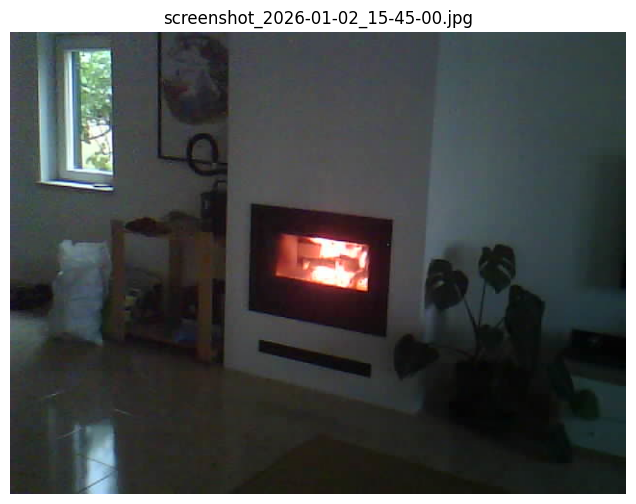

In [4]:
test_image_n = 300
test_image_path = Path(all_files[test_image_n])
test_image = test_image_path.name

img = load_image(test_image_path)

plot_image(img, title=test_image)

In [5]:
# Extract features and keep paths
X = []
paths = []
for path in image_paths:
    img = load_image(path)
    warped = warp_polygon_to_square(img, FIREPLACE_POLY, OUTPUT_SIZE)
    feats = extract_features(warped, N_BANDS, HOT_PIXEL_V_THRESHOLD)
    X.append(feats)
    paths.append(path)

X = np.vstack(X)
print("Feature matrix shape:", X.shape)

Feature matrix shape: (111, 18)


In [6]:
df_X = pd.DataFrame(X)
# df_X.describe()

In [7]:
# KMeans clustering
kmeans = KMeans(n_clusters=N_CLUSTER, random_state=random_state)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Find 5 closest images to each centroid
distances = cdist(X, centroids)

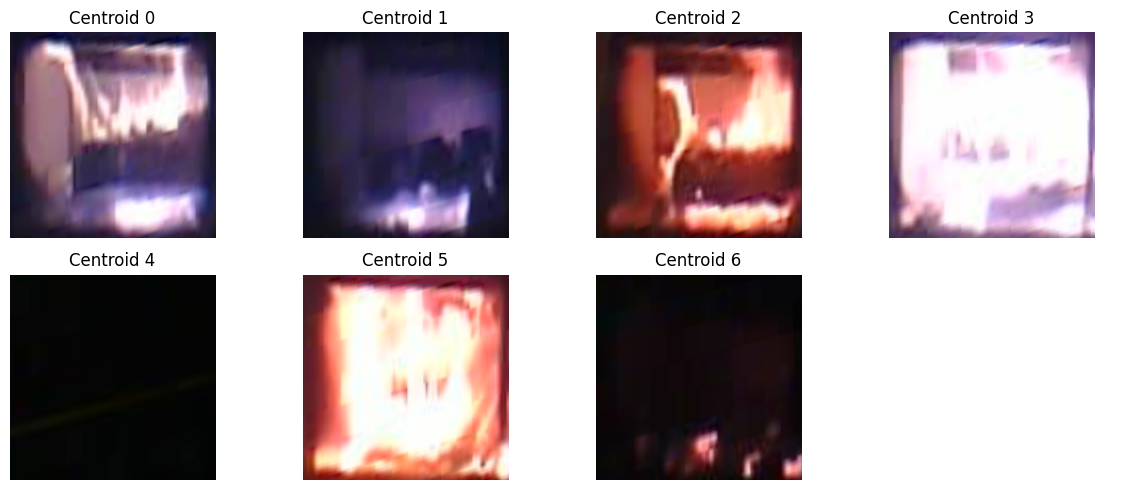

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5))
axes = axes.flatten()
plot_idx = 0

for i in range(N_CLUSTER):
    idx_sorted = np.argsort(distances[:, i])[:1]
    for idx in idx_sorted:
        img = load_image(paths[idx])
        warped = warp_polygon_to_square(img, FIREPLACE_POLY, OUTPUT_SIZE)

        ax = axes[plot_idx]
        ax.imshow(warped)
        ax.set_title(f"Centroid {i}")
        ax.axis("off")

        plot_idx += 1

for j in range(plot_idx, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [9]:
cluster_to_label = {
    0: "medium flames",
    1: "small flames",
    2: "medium flames",
    3: "large flames",
    4: "black",
    5: "large flames",
    6: "embers",
}

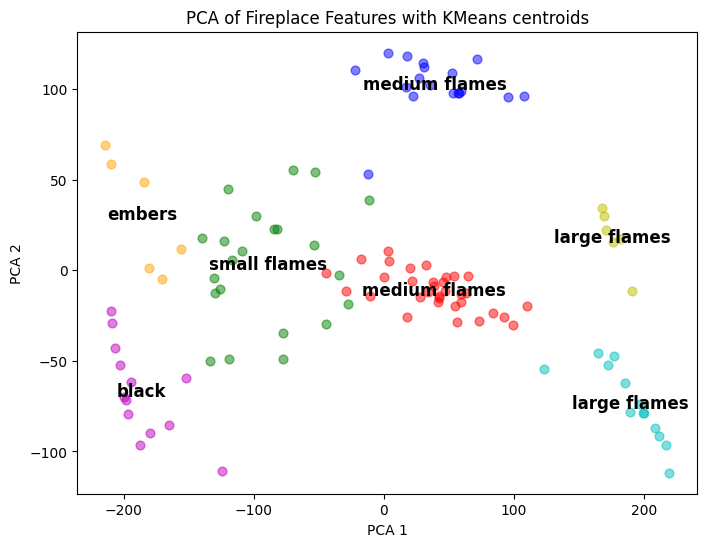

In [10]:
# PCA scatter plot with centroids
pca = PCA(n_components=2, random_state=random_state)
X_2d = pca.fit_transform(X)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(8,6))
colors = ["r", "g", "b", "c", "m", "y", "orange", "purple", "brown", "pink"]

for k in range(N_CLUSTER):
    mask = labels == k
    
    # Plot cluster points
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=colors[k],
        alpha=0.5,
        s=40
    )
    
    # plt.scatter(
    #     centroids_2d[k, 0],
    #     centroids_2d[k, 1],
    #     c=colors[k],
    #     edgecolor="k",
    #     s=200,
    #     marker="x"
    # )
    
    # Add text annotation at centroid
    plt.annotate(
        cluster_to_label.get(k),
        (centroids_2d[k, 0], centroids_2d[k, 1]),
        textcoords="offset points",
        xytext=(0, 0),
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='black'
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA of Fireplace Features with KMeans centroids")
plt.show()

# Train Classifier

In [11]:
y = np.array([cluster_to_label[l] for l in labels])

clf = RandomForestClassifier(n_estimators=200, random_state=random_state)
clf.fit(X, y)

# Save model
joblib.dump(clf, DIR_PATH /'models'/ f'{MODEL_NAME}.joblib')

['../models/random_forest_v1.2.joblib']

# Validate

Predicted category: medium flames
Prediction probabilities:
  black: 0.000
  embers: 0.000
  large flames: 0.460
  medium flames: 0.535
  small flames: 0.005


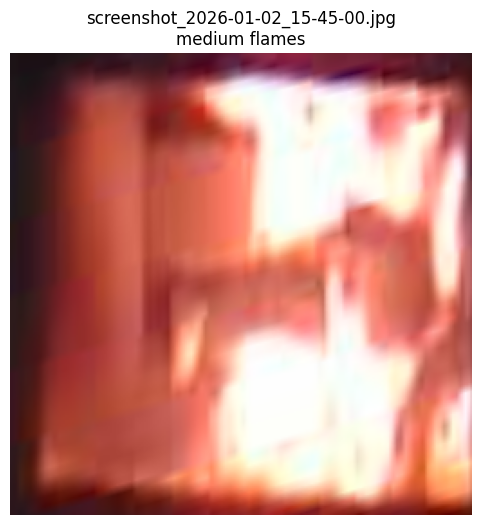

In [12]:
# Load, warp, extract features
img_new = load_image(test_image_path)
warped_new = warp_polygon_to_square(img_new, FIREPLACE_POLY, OUTPUT_SIZE)
features_new = extract_features(warped_new, N_BANDS, HOT_PIXEL_V_THRESHOLD).reshape(1, -1)

# Predict label
pred_label = clf.predict(features_new)[0]
pred_proba = clf.predict_proba(features_new)[0]

print(f"Predicted category: {pred_label}")
print("Prediction probabilities:")
for cat, prob in zip(clf.classes_, pred_proba):
    print(f"  {cat}: {prob:.3f}")

plot_image(warped_new, title=test_image + f"\n{pred_label}")


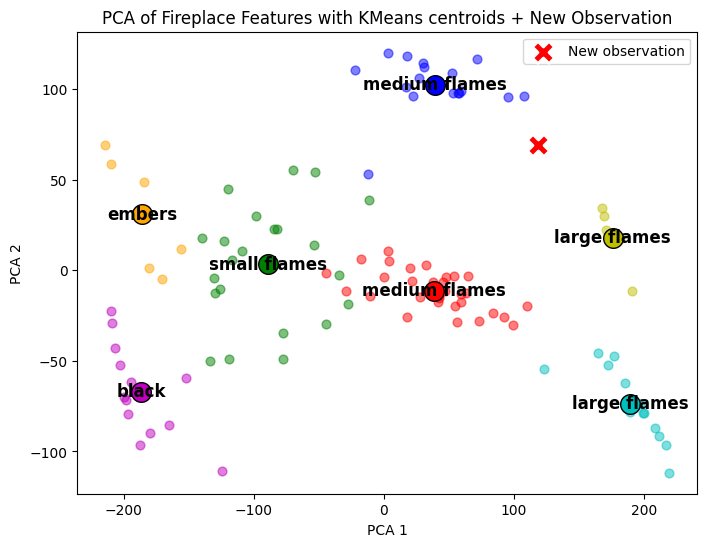

In [13]:
# Project new observation(s)
X_2d_val = pca.transform(features_new)

plt.figure(figsize=(8,6))
colors = ["r", "g", "b", "c", "m", "y", "orange", "purple", "brown", "pink"]

for k in range(N_CLUSTER):
    mask = labels == k
    
    # Cluster points
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=colors[k],
        alpha=0.5,
        s=40
    )
    
    # Centroid
    plt.scatter(
        centroids_2d[k, 0],
        centroids_2d[k, 1],
        c=colors[k],
        edgecolor="k",
        s=200,
        marker="o"
    )
    
    # Centroid label
    plt.annotate(
        cluster_to_label.get(k),
        (centroids_2d[k, 0], centroids_2d[k, 1]),
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='black'
    )

# ---- NEW OBSERVATION ----
plt.scatter(
    X_2d_val[:, 0],
    X_2d_val[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolor="white",
    linewidth=2,
    label="New observation"
)


plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA of Fireplace Features with KMeans centroids + New Observation")
plt.legend()
plt.show()